# Imports

In [19]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

# Loading env variables

In [20]:
load_dotenv()

True

# Define LLM

In [21]:
model = ChatOpenAI()

# Define State

In [22]:
class Blogstate(TypedDict):
    title: str
    outline: str
    content:str
    

# Creating Nodes

In [23]:
def create_outline(state: Blogstate) -> Blogstate:

     # fetch title
    title = state['title']

    # call llm gen outline
    prompt= f'Generate a detailed outline for a blog on the topic - {title}'
    outline= model.invoke(prompt).content

    # update state
    state['outline']= outline

    return state




In [24]:
def create_blog(state: Blogstate) -> Blogstate:
    title = state['title']
    outline = state['outline']

       
    prompt  = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content= model.invoke(prompt  ).content
    state['content']= content

    return state


# Define and Compile Graph

In [25]:
graph= StateGraph(Blogstate)

# nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)

#edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

workflow= graph.compile()

# Execute the Graph

In [26]:
initial_state= {'title':'Raise of AI in the united states of America '}
final_state= workflow.invoke(initial_state)
print(final_state)

{'title': 'Raise of AI in the united states of America ', 'outline': 'I. Introduction\n   A. Brief overview of the rise of AI technology in the United States\n   B. Importance of AI in various industries\n   C. Purpose of the blog\n\nII. History of AI in the United States\n   A. Early development of AI technology\n   B. Milestones in AI research and development\n   C. Adoption of AI in different sectors\n\nIII. Impact of AI on the US economy\n   A. Job displacement and creation\n   B. Increased efficiency and productivity\n   C. Opportunities for innovation and growth\n\nIV. AI in healthcare\n   A. Use of AI in medical diagnosis and treatment\n   B. AI-powered research and drug development\n   C. Ethical considerations in AI healthcare applications\n\nV. AI in education\n   A. Personalized learning with AI technology\n   B. Automation in administrative tasks\n   C. Challenges and concerns in integrating AI into education\n\nVI. AI in finance\n   A. Algorithmic trading and risk manageme

In [27]:
print(final_state['outline'])

I. Introduction
   A. Brief overview of the rise of AI technology in the United States
   B. Importance of AI in various industries
   C. Purpose of the blog

II. History of AI in the United States
   A. Early development of AI technology
   B. Milestones in AI research and development
   C. Adoption of AI in different sectors

III. Impact of AI on the US economy
   A. Job displacement and creation
   B. Increased efficiency and productivity
   C. Opportunities for innovation and growth

IV. AI in healthcare
   A. Use of AI in medical diagnosis and treatment
   B. AI-powered research and drug development
   C. Ethical considerations in AI healthcare applications

V. AI in education
   A. Personalized learning with AI technology
   B. Automation in administrative tasks
   C. Challenges and concerns in integrating AI into education

VI. AI in finance
   A. Algorithmic trading and risk management
   B. Fraud detection and prevention
   C. Regulatory implications of AI in the financial sec

In [28]:
print(final_state['content'])

I. Introduction

A. The rise of Artificial Intelligence (AI) technology in the United States has been exponential in recent years, transforming various industries and sectors in profound ways. 
B. AI has become increasingly important in sectors such as healthcare, finance, transportation, and education, revolutionizing processes and improving efficiency.
C. The purpose of this blog is to explore the history, impact, challenges, and future prospects of AI in the United States, highlighting its significance in shaping the country's economy and society.

II. History of AI in the United States

A. The development of AI technology dates back to the 1950s, with pioneers such as John McCarthy and Marvin Minsky laying the foundations for AI research.
B. Milestones in AI research and development include the creation of expert systems in the 1980s, the emergence of machine learning algorithms in the 2000s, and the rise of deep learning and neural networks in recent years.
C. AI has been adopted 

# Visualize Graph (Optional)

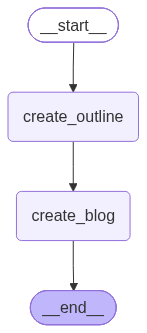

In [29]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())